In [1]:
from pathlib import Path
from utility import get_profiler_result, search_profiler_file
from perf_estimator.estimator import Estimator, TrainerEstimator
from perf_estimator.dataset import image_dataset


In [24]:
model = "MobeNetV3Large"
batch_size = 410
optimizer = "Adam"
root_dir = Path("/home/glaswigian/Documents/200-ResearchData/101-xMem-LLM")
paper_data_dir = root_dir / "003-Paper-profiling" / f"recurrence-{model}-{optimizer}-{batch_size}-1"
tainer_data_dir = root_dir / "001-CPU-profiling" / f"{model}-{batch_size}-{optimizer}"

In [25]:
paper_data_file = search_profiler_file(paper_data_dir)[-2]
tainer_data_file = search_profiler_file(tainer_data_dir)[-1]
print(
    f"paper_data_file: {paper_data_file}\n"
    f"Tainer_data_file: {tainer_data_file}\n"
)

paper_data_file: /home/glaswigian/Documents/200-ResearchData/101-xMem-LLM/003-Paper-profiling/recurrence-MobeNetV3Large-Adam-410-1/20241127-152338-9302/results/profiler/5cd681683997_1.1732721034589923022.pt.trace.json
Tainer_data_file: /home/glaswigian/Documents/200-ResearchData/101-xMem-LLM/001-CPU-profiling/MobeNetV3Large-410-Adam/results/callback/Profiler/Glaswigian-Researcher_73974.1740983855095173582.pt.trace.json



In [26]:
paper_result = Estimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=paper_data_file,
    max_gpu_memory_in_gb=8,
)
paper_result, _ = paper_result.estimate()


In [27]:
tainer_result = TrainerEstimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=tainer_data_file,
    max_gpu_memory_in_gb=8,
)
tainer_result, _ = tainer_result.estimate()


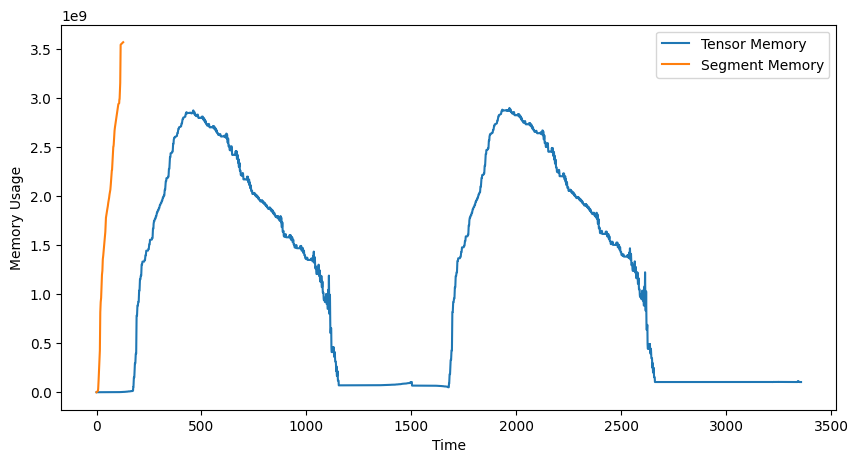

In [28]:
paper_result.plot_memory_change()

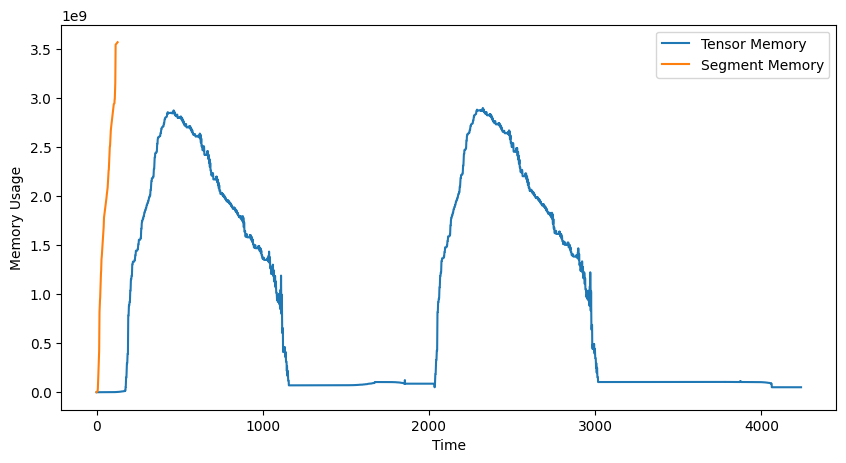

In [29]:
tainer_result.plot_memory_change()

In [30]:
print(f"Paper max seg: {max(paper_result._trace.max_segment_changes)}")
print(f"Paper max seg: {max(tainer_result._trace.max_segment_changes)}")


Paper max seg: 3571449856
Paper max seg: 3571449856
